In [1]:
import matplotlib.pyplot as plt
import numpy as np

from offers.companies.visionite import (
    SimulationConfig,
    StrategyMonteCarlo,
    calc_compensation,
    find_itp1_pension,
)
from offers.logging_config import configure_logging
from offers.tax import salary_sweep

configure_logging()

In [2]:
income = 120960
pot = 3000
car = 0

pension = find_itp1_pension(income=income, pot=pot, car=car)
pension = 10000

total_compensation = calc_compensation(
    income=income,
    pension=pension,
    pot=pot,
    car=car,
)
total_compensation.print_table()

───────────────────────────────────────────────── 
   Egen intäkt                        120 960 kr   
 ───────────────────────────────────────────────── 
   Skatter och avgifter                            
 ───────────────────────────────────────────────── 
   Semesteravsättning                   9 964 kr   
 ───────────────────────────────────────────────── 
   Arbetsverktyg & Trygghetspaket       1 500 kr   
 ───────────────────────────────────────────────── 
   Arbetsgivaravgifter                 24 873 kr   
 ───────────────────────────────────────────────── 
   Löneskatt på tjänstepension          2 426 kr   
 ───────────────────────────────────────────────── 
   Bruttolön                           69 197 kr   
 ───────────────────────────────────────────────── 
   Tjänstepension                      10 000 kr   
 ───────────────────────────────────────────────── 
   Sparande till Visionitekonto         3 000 kr   
 ───────────────────────────────────────────────── 
   Bilkostnad                               0 kr   
 ───────────────────────────────────────────────── 
   Tabellskatt                         20 871 kr   
 ───────────────────────────────────────────────── 
   Nettolön                            48 326 kr   
 ─────────────────────────────────────────────────

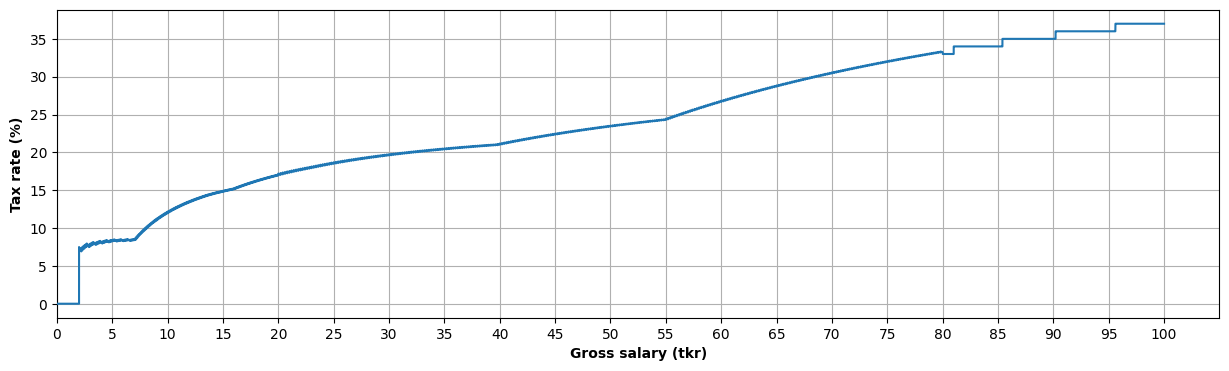

In [3]:
df = salary_sweep(high=100000)
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(df["salary"]*1e-3, 100 * df["tax"]/ df["salary"], zorder=3)
ax.grid(zorder=1)
ax.set_xticks(np.arange(0, 101, 5))
ax.set_xlim(0, None)
ax.set_xlabel("Gross salary (tkr)", fontweight="bold")
ax.set_ylabel("Tax rate (%)", fontweight="bold")
plt.show()

# Monte-Carlo simulation

In [8]:
%%timeit
config = SimulationConfig(
    total_income=120960,
    pension=7332,
    car_cost=0,
    monthly_salary_investment=2500,
    monthly_mean_return=1.20 ** (1/12) - 1,
    monthly_volatility=0.15 / 12**0.5,
    months_between_withdrawals=6,
    n_months=12 * 3,
    n_simulations=10000,
)

sim = StrategyMonteCarlo(config)
res = sim.run()

2.24 s ± 85.5 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [12]:
pension = [5500, 7000, 10000]
monthly_salary_investment = [0, 2500, 5000, 7500, 10000]
months_between_withdrawals = [6, 12, 18]
n_months = np.array([1, 2, 3, 4]) * 12

3 * 5 * 3 * 4

180

1835428 1825619


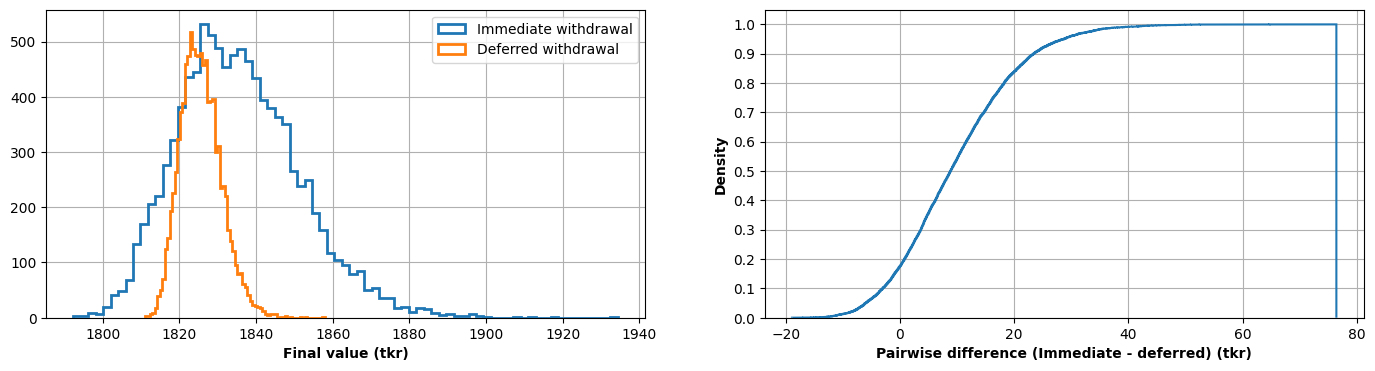

,immediate_withdrawal_final,deferred_withdrawal_final,advantage_final
mean,1835.4,1825.6,9.80
std,15.8,5.3,10.60
p05,1811.8,1817.7,-6.00
p25,1824.2,1821.9,2.30
p50,1834.2,1825.2,8.90
p75,1845.4,1828.9,16.40
p95,1863.7,1835.0,28.70
win_probability_immediate_withdrawal,NaN,NaN,0.83
paired_effect_size_dz,NaN,NaN,0.93
advantage_skewness,NaN,NaN,0.56


In [ ]:
config = SimulationConfig(
    total_income=120960,
    pension=7332,
    car_cost=0,
    monthly_salary_investment=2500,
    monthly_mean_return=1.20 ** (1/12) - 1,
    monthly_volatility=0.15 / 12**0.5,
    months_between_withdrawals=6,
    n_months=12 * 3,
    n_simulations=10000,
)

sim = StrategyMonteCarlo(config)
res = sim.run()

# Plot final-value distributions
immediate_final = res.immediate_withdrawal_values[:, -1]
deferred_final = res.deferred_withdrawal_values[:, -1]
print(round(immediate_final.mean()), round(deferred_final.mean()))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 4))
for label, values in zip(
    ["Immediate withdrawal", "Deferred withdrawal"],
    [immediate_final, deferred_final],
):
    ax1.hist(
        values*1e-3,
        bins="auto",
        histtype="step",
        linewidth=2,
        cumulative=False,
        density=False,
        label=label,
        zorder=3,
    )
ax1.grid(zorder=1)
ax1.legend()
ax1.set_xlabel("Final value (tkr)", fontweight="bold")

ax2.hist(
    res.final_advantage*1e-3,
    bins=1000,
    histtype="step",
    linewidth=1.5,
    cumulative=True,
    density=True,
    zorder=3,
)
ax2.grid(zorder=1)
ax2.set_yticks(np.arange(0, 1.01, 0.1))
ax2.set_xlabel("Pairwise difference (Immediate - deferred) (tkr)", fontweight="bold")
ax2.set_ylabel("Density", fontweight="bold")
plt.show()

res.summary_table

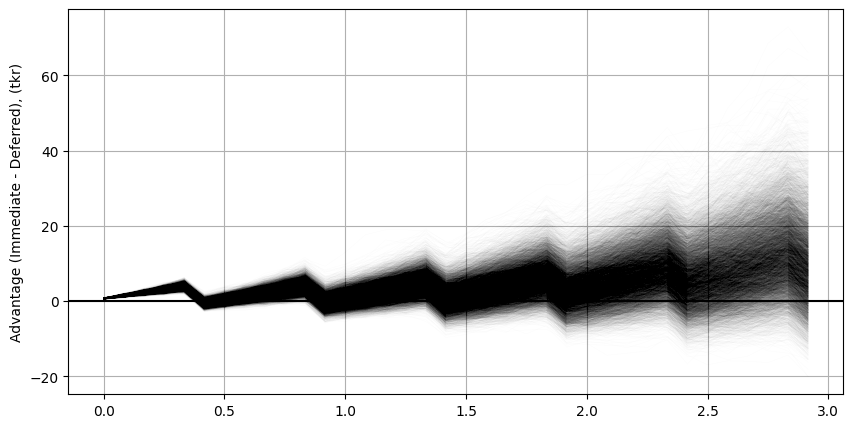

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(res.advantage.shape[1])
ax.plot(
    x / 12,
    res.advantage.T * 1e-3,
    alpha=0.01,
    color="k",
    linewidth=0.5,
    zorder=3,
)
ax.grid(zorder=1)
ax.axhline(0, color="k", zorder=2)
ax.set_ylabel("Advantage (Immediate - Deferred), (tkr)")
plt.show()